# Graph IV

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [2]:
class AgentState(TypedDict):
  number1: int
  operation: str
  number2: int
  finalNumber: int

In [8]:
def adder(state: AgentState)-> AgentState:
  """This node adds the 2 numbers"""

  state["finalNumber"] = state['number1'] + state['number2']
  return state

def substrator(state: AgentState)-> AgentState:
  """This node substract the 2 numbers"""

  state["finalNumber"] = state['number1'] - state['number2']
  return state

def decide_next_node(state: AgentState) -> str:
  """This node will select the next node of the graph"""

  if state['operation'] == "+":
    return "addition_operation"
  elif state['operation'] == "-":
    return "substraction_operation"

In [10]:
graph = StateGraph(AgentState)

graph.add_node("add_node", adder)
graph.add_node("substract_node", substrator)
graph.add_node("router", lambda state:state) # passthough function

graph.add_edge(START, "router")
graph.add_conditional_edges(
  "router",
  decide_next_node,
  {
    "addition_operation": "add_node",
    "substraction_operation": "substract_node"
  }
)

graph.add_edge("add_node",END)
graph.add_edge("substract_node",END)

app = graph.compile()

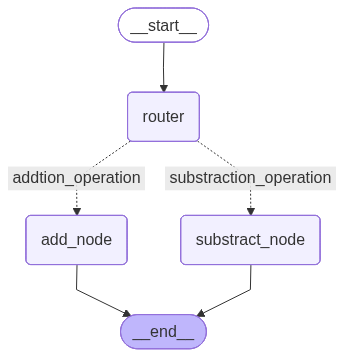

In [6]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [11]:
initial_state_1 = AgentState(number1=10, operation="-", number2=5)
print(app.invoke(initial_state_1))

{'number1': 10, 'operation': '-', 'number2': 5, 'finalNumber': 5}


# Exercise

In [26]:
class AgentState(TypedDict):
  number1: int
  operation: str
  number2: int
  finalNumber: int
  number3: int
  operation2: str
  number4: int
  finalNumber2: int

In [27]:
def adder2(state: AgentState)-> AgentState:
  """This node adds the 2 numbers"""

  state["finalNumber2"] = state['number3'] + state['number4']
  return state

def substrator2(state: AgentState)-> AgentState:
  """This node substract the 2 numbers"""

  state["finalNumber2"] = state['number3'] - state['number4']
  return state

def decide_next_node2(state: AgentState) -> str:
  """This node will select the next node of the graph"""

  if state['operation2'] == "+":
    return "addition_operation"
  elif state['operation2'] == "-":
    return "substraction_operation"


In [28]:
second_graph = StateGraph(AgentState)

second_graph.add_node("add_node", adder)
second_graph.add_node("substract_node", substrator)
second_graph.add_node("router", lambda state:state) # passthough function
second_graph.add_node("router2", lambda state:state) # passthough function
second_graph.add_node("add_node2", adder2)
second_graph.add_node("substract_node2", substrator2)

second_graph.add_edge(START, "router")
second_graph.add_conditional_edges(
  "router",
  decide_next_node,
  {
    "addition_operation": "add_node",
    "substraction_operation": "substract_node"
  }
)

second_graph.add_edge("add_node","router2")
second_graph.add_edge("substract_node","router2")

second_graph.add_conditional_edges(
  "router2",
  decide_next_node2,
  {
    "addition_operation": "add_node2",
    "substraction_operation": "substract_node2"
  }
)

second_graph.add_edge("add_node2", END)
second_graph.add_edge("substract_node2", END)

second_app = second_graph.compile()

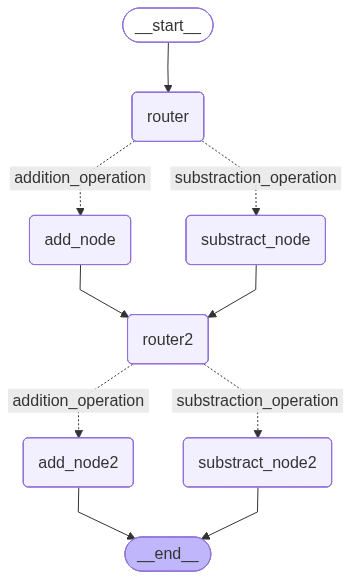

In [20]:
from IPython.display import Image, display
display(Image(second_app.get_graph().draw_mermaid_png()))

In [29]:
initial_state_1 = AgentState(number1=10, operation="-", number2=5,number3=1,number4=1,operation2="+")
print(second_app.invoke(initial_state_1))

{'number1': 10, 'operation': '-', 'number2': 5, 'finalNumber': 5, 'number3': 1, 'operation2': '+', 'number4': 1, 'finalNumber2': 2}
